Churn Risk Class Balance:
            Count  Percent
Churn_Risk                
Low          2695     50.0
High         2695     50.0


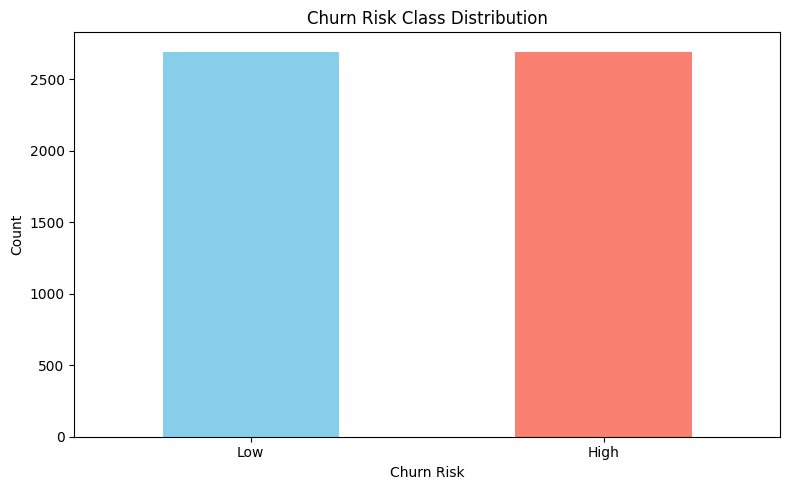

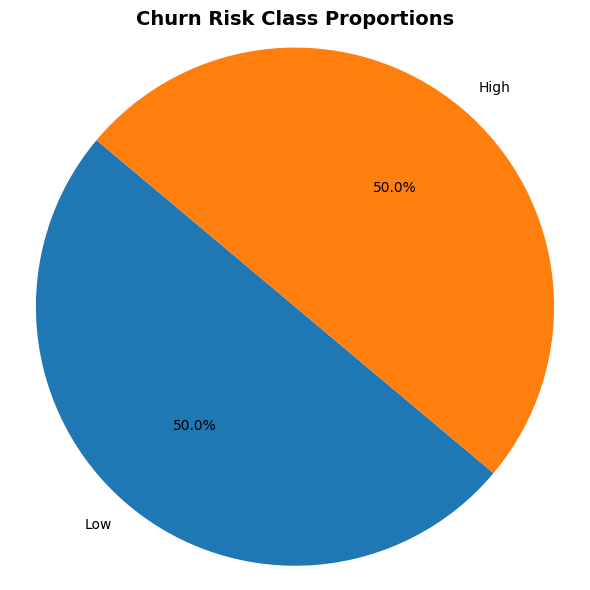

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Specify the path to your CSV file
file_path = "/content/testdata_over.csv"
# 2) Load the dataset
df = pd.read_csv(file_path)

# 3) Compute class counts and percentages
counts = df['Churn_Risk'].value_counts(dropna=False)
percentages = (counts / counts.sum() * 100).round(2)
balance_df = pd.DataFrame({
    'Count': counts,
    'Percent': percentages
})

# 4) Print the balance table
print("Churn Risk Class Balance:")
print(balance_df)

# 5) Bar chart of class counts
plt.figure(figsize=(8, 5))
counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Churn Risk Class Distribution")
plt.xlabel("Churn Risk")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 6) Pie chart of class proportions
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Churn Risk Class Proportions", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Balancing Data Using RandomUnderSampler

In [ ]:
import pandas as pd
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

# 1) Load your test set
df = pd.read_csv("modified_formatting_data.csv")

# 2) Separate features & target
X = df.drop(columns=["Churn_Risk"], errors="ignore")
y = df["Churn_Risk"].astype(str)

# 3) Examine original distribution
orig_counts = Counter(y)
print("Original class distribution:", orig_counts)

# 4) Apply RandomUnderSampler to balance classes 50/50
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X, y)

# 5) Verify new distribution
new_counts = Counter(y_under)
print("Under-sampled class distribution:", new_counts)

# 6) Recombine into a single DataFrame
df_under = X_under.copy()
df_under["Churn_Risk"] = y_under

# 7) Save the under-sampled dataset
df_under.to_csv("testdata_under.csv", index=False)
print("Under-sampled dataset saved to testdata_under.csv")


Original class distribution: Counter({'Low': 2695, 'High': 305})
Under-sampled class distribution: Counter({'High': 305, 'Low': 305})
Under-sampled dataset saved to testdata_under.csv


# Balancing Test Data Using RandomOversampler

In [ ]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

# 1) Load your test set
df = pd.read_csv("modified_formatting_data.csv")

# 2) Separate features & target
X = df.drop(columns=["Churn_Risk"], errors="ignore")
y = df["Churn_Risk"].astype(str)

# 3) Examine original distribution
orig_counts = Counter(y)
print("Original class distribution:", orig_counts)

# 4) Apply RandomOverSampler to balance classes 50/50
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X, y)

# 5) Verify new distribution
new_counts = Counter(y_over)
print("Over-sampled class distribution:", new_counts)

# 6) Recombine into a single DataFrame
df_over = X_over.copy()
df_over["Churn_Risk"] = y_over

# 7) Save the over-sampled dataset
df_over.to_csv("testdata_over.csv", index=False)
print("Over-sampled dataset saved to testdata_over.csv")


Original class distribution: Counter({'Low': 2695, 'High': 305})
Over-sampled class distribution: Counter({'Low': 2695, 'High': 2695})
Over-sampled dataset saved to testdata_over.csv


# Balancing Test Data Using SMOTE

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder

# 1) Load the raw test set
df = pd.read_csv("modified_formatting_data.csv")

# 2) Separate features and target
X = df.drop(columns=["Churn_Risk"], errors="ignore")
y = df["Churn_Risk"].astype(str)

# 3) Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# 4) Ordinal-encode categorical columns
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat = enc.fit_transform(X[cat_cols])
X_num = X[num_cols].to_numpy()

# 5) Stack them together
X_enc = np.hstack([X_cat, X_num])

# 6) Tell SMOTENC which indices are categorical
cat_indices = list(range(len(cat_cols)))

# 7) Apply SMOTE for mixed data
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_res, y_res = smote_nc.fit_resample(X_enc, y)

# 8) Split the resampled array back into cats & nums
X_cat_res = X_res[:, :len(cat_cols)]
X_num_res = X_res[:, len(cat_cols):]

# 9) Inverse-transform the categories to original labels
#    (round to nearest integer before inverse)
X_cat_orig = enc.inverse_transform(np.round(X_cat_res).astype(int))

# 10) Rebuild a DataFrame with original column names
df_res_num = pd.DataFrame(X_num_res, columns=num_cols)
df_res_cat = pd.DataFrame(X_cat_orig, columns=cat_cols)
df_smote   = pd.concat([df_res_cat, df_res_num], axis=1)
df_smote["Churn_Risk"] = y_res

# 11) Save and report
df_smote.to_csv("testdata_smote.csv", index=False)
print("Balanced distribution:", Counter(y_res))
print("Saved balanced file → testdata_smote.csv")


Balanced distribution: Counter({'Low': 2695, 'High': 2695})
Saved balanced file → testdata_smote.csv


In [ ]:
df

,Location,Zip Code,Age,Gender,Language,Product Name,Avg Order Value,Cart Abandoned,Payment Method,Page Views,...,Impressions,Coupon_Code_Usage,Product_Bundling_Preferences,Churn_Risk,Repeat_Purchase_Decline,Discounted,Return_Rate,Defective_Flag,Channel,Is_Existing_Customer
0,London,46880,39,Male,Chinese,Dairy Milk,74.770000,1.0,PayPal,22,...,5142,2,Candy & Gum,Low,49.00096,True,15.66809,1,Web,1
1,NewYork,14720,34,Male,Chinese,Tang,74.480000,0.0,Credit Card,35,...,5142,2,Candy & Gum,Low,49.00096,True,15.66809,1,Web,1
2,Sydney,98108,40,Male,French,Mirinda,66.020000,0.0,UPI,40,...,5142,2,Candy & Gum,Low,49.00096,True,15.66809,1,Web,1
3,NewYork,13640,23,Female,Chinese,Star,17.780000,1.0,PayPal,37,...,5142,2,Candy & Gum,Low,49.00096,True,15.66809,1,Web,1
4,Toronto,61759,33,Other,French,Halls,31.200000,0.0,UPI,33,...,5142,2,Candy & Gum,Low,49.00096,True,15.66809,1,Web,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,USA,54374,42,Other,English,Generic Product,180.042972,1.0,UPI,25,...,9356,0,Candy & Gum,Low,49.19000,True,10.66000,0,Web,1
2996,Brazil,54374,42,Other,English,Generic Product,230.491382,3.0,PayPal,25,...,3034,5,Candy & Gum,Low,82.25000,False,4.62000,1,Web,1
2997,India,54374,42,Other,English,Generic Product,255.648748,3.0,Cash on Delivery,25,...,1845,5,Beverages & Snacks,High,40.60000,True,20.72000,0,Mobile App,1
2998,UK,54374,42,Other,English,Generic Product,250.599579,4.0,Debit Card,25,...,7292,5,Chocolate & Biscuits,Low,98.47000,True,28.81000,0,Mobile App,1


In [ ]:
df_under

,Location,Zip Code,Age,Gender,Language,Product Name,Avg Order Value,Cart Abandoned,Payment Method,Page Views,...,Impressions,Coupon_Code_Usage,Product_Bundling_Preferences,Repeat_Purchase_Decline,Discounted,Return_Rate,Defective_Flag,Channel,Is_Existing_Customer,Churn_Risk
2002,India,54374,42,Other,English,Generic Product,27.675924,0.0,UPI,25,...,2209,1,Beverages & Snacks,97.39000,False,15.29000,0,In-Store,1,High
2011,Germany,54374,42,Other,English,Generic Product,119.255245,4.0,Debit Card,25,...,6938,4,Chocolate & Biscuits,18.11000,True,26.88000,1,Web,1,High
2024,India,54374,42,Other,English,Generic Product,131.202953,4.0,Cash on Delivery,25,...,6139,2,Chocolate & Biscuits,0.41000,False,25.46000,1,In-Store,1,High
2025,UK,54374,42,Other,English,Generic Product,303.851808,3.0,UPI,25,...,6082,0,Chocolate & Biscuits,34.29000,False,4.89000,0,Web,1,High
2029,Germany,54374,42,Other,English,Generic Product,201.124248,4.0,Cash on Delivery,25,...,9330,5,Candy & Gum,19.26000,True,11.40000,1,Web,1,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,USA,54374,42,Other,English,Generic Product,180.042972,1.0,UPI,25,...,9356,0,Candy & Gum,49.19000,True,10.66000,0,Web,1,Low
1957,Toronto,54374,42,Other,English,Generic Product,154.714715,0.0,UPI,25,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,0,Low
1463,Toronto,54374,42,Other,English,Generic Product,154.714715,1.0,UPI,25,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,1,Low
1674,Toronto,54374,42,Other,English,Generic Product,154.714715,0.0,UPI,25,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,0,Low


In [ ]:
df_smote

,Location,Gender,Language,Product Name,Payment Method,Time Spent (min),Clickstream Data,Search Query,Support Queries,Survey Response,...,Wishlist_Adds,Return_Refund_Rate,Ad_Clicks,Impressions,Coupon_Code_Usage,Repeat_Purchase_Decline,Return_Rate,Defective_Flag,Is_Existing_Customer,Churn_Risk
0,London,Male,Chinese,Dairy Milk,PayPal,00:12:05,Home > Chocolate > Dairy Milk,Snacks,Payment Issue,Negative,...,1.000000,0.515290,9.000000,5142.000000,2.000000,49.000960,15.668090,1.000000,1.0,Low
1,NewYork,Male,Chinese,Tang,Credit Card,00:18:37,Home > Beverages > Tang,Tang,Payment Issue,Positive,...,1.000000,0.515290,9.000000,5142.000000,2.000000,49.000960,15.668090,1.000000,1.0,Low
2,Sydney,Male,French,Mirinda,UPI,00:13:07,Home > Beverages > Mirinda,Mirinda,Product Complaint,Positive,...,1.000000,0.515290,9.000000,5142.000000,2.000000,49.000960,15.668090,1.000000,1.0,Low
3,NewYork,Female,Chinese,Star,PayPal,00:11:49,Home > Chocolate > 5 Star,5 Star,Delayed Order,Neutral,...,1.000000,0.515290,9.000000,5142.000000,2.000000,49.000960,15.668090,1.000000,1.0,Low
4,Toronto,Other,French,Halls,UPI,00:02:45,Home > Candy > Halls,Halls,Product Complaint,Positive,...,1.000000,0.515290,9.000000,5142.000000,2.000000,49.000960,15.668090,1.000000,1.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5385,Germany,Other,English,Generic Product,Debit Card,00:11:03,15,Gum,Delayed Order,Negative,...,0.900263,0.140026,11.900263,3236.118138,2.649606,19.214770,24.927085,0.549869,1.0,High
5386,Brazil,Other,English,Generic Product,UPI,00:11:03,9,Gum,Delayed Order,Negative,...,1.050573,0.346183,12.443696,1178.600140,2.050573,40.556311,8.061517,0.949427,1.0,High
5387,Brazil,Other,English,Generic Product,UPI,00:11:03,12,Gum,Delayed Order,Negative,...,2.573879,0.300172,12.556727,4119.941942,0.000000,46.529623,3.157453,1.000000,1.0,High
5388,India,Other,English,Generic Product,UPI,00:11:03,13,Gum,Delayed Order,Negative,...,2.664727,0.635378,13.658908,3604.186200,3.167636,64.660330,26.533998,0.832364,1.0,High


In [ ]:
df_over

,Location,Zip Code,Age,Gender,Language,Product Name,Avg Order Value,Cart Abandoned,Payment Method,Page Views,...,Impressions,Coupon_Code_Usage,Product_Bundling_Preferences,Repeat_Purchase_Decline,Discounted,Return_Rate,Defective_Flag,Channel,Is_Existing_Customer,Churn_Risk
0,London,46880,39,Male,Chinese,Dairy Milk,74.770000,1.0,PayPal,22,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,1,Low
1,NewYork,14720,34,Male,Chinese,Tang,74.480000,0.0,Credit Card,35,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,1,Low
2,Sydney,98108,40,Male,French,Mirinda,66.020000,0.0,UPI,40,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,1,Low
3,NewYork,13640,23,Female,Chinese,Star,17.780000,1.0,PayPal,37,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,1,Low
4,Toronto,61759,33,Other,French,Halls,31.200000,0.0,UPI,33,...,5142,2,Candy & Gum,49.00096,True,15.66809,1,Web,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5385,India,54374,42,Other,English,Generic Product,475.684250,3.0,Credit Card,25,...,2819,3,Candy & Gum,65.27000,False,26.93000,0,Web,1,High
5386,Germany,54374,42,Other,English,Generic Product,380.919336,4.0,UPI,25,...,6846,5,Candy & Gum,72.27000,True,18.28000,0,Web,1,High
5387,Australia,54374,42,Other,English,Generic Product,229.416204,4.0,UPI,25,...,7020,3,Beverages & Snacks,25.05000,False,20.90000,1,Mobile App,1,High
5388,Germany,54374,42,Other,English,Generic Product,396.622368,0.0,Cash on Delivery,25,...,4134,4,Beverages & Snacks,57.32000,True,12.28000,1,Web,1,High


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# 1) Load cleaned data
df = pd.read_csv("cleaned_data.csv")

# 2) Encode your historic churn-risk strings into integer labels
y_raw = df["Churn_Risk"].astype(str)
y, class_names = pd.factorize(y_raw)
print("Class mapping:", dict(enumerate(class_names)))

# 3) Drop non-predictive columns (including the original churn column)
to_drop = [
    "Name", "Email", "Customer ID", "Transaction Date", "IP Address",
    "POS_Transaction_ID", "Zip Code", "Product Name", "Language",
    "Store_Location_City", "Store_Location_Country",
    "Delivery_Location_City", "Delivery_Location_Country",
    "Referral Source", "Cluster", "Customer_Type",
    "Churn_Risk"
]
X = df.drop(columns=to_drop, errors="ignore")

# 4) Preprocessing: ordinal-encode categoricals, scale numericals
categorical_cols = X.select_dtypes(include=['object','category']).columns.tolist()
numerical_cols   = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
], remainder='drop')

X_proc = preprocessor.fit_transform(X)

# 5) Mutual-information feature selection on full data
total_feats    = X_proc.shape[1]
discrete_flags = [True]*len(categorical_cols) + [False]*(total_feats - len(categorical_cols))

mi_scores = mutual_info_classif(X_proc, y, discrete_features=discrete_flags)
feat_names = (
    preprocessor.named_transformers_['cat']
                .get_feature_names_out(categorical_cols).tolist()
  + numerical_cols
)

mi_df  = pd.DataFrame({'feature': feat_names, 'mi_score': mi_scores})
top_10 = mi_df.nlargest(10, 'mi_score')['feature'].tolist()
print("Top 10 predictive features:\n", top_10)

# 6) Subset to top 10 features
X_sel = pd.DataFrame(X_proc, columns=feat_names)[top_10]

# 7) Train RandomForest on 100% of data
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_sel, y)

print("\nModel trained on 100% of the data.")


Class mapping: {0: 'Low', 1: 'High'}
Top 10 predictive features:
 ['Order_ID', 'First Interaction Date', 'Location', 'Ticket Resolution Time', 'source', 'Average Resolution Time', 'Average Response Time', 'Product Price', 'Return_Refund_Rate', 'Return_Rate']

Model trained on 100% of the data.


# Random Forest

In [ ]:
import json
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)

# 1) Load config
with open("config.json") as f:
    cfg = json.load(f)
proxy_features = cfg["dataset"]["proxy_features"]
target_col     = cfg["dataset"]["target_variable"]

# 2) Read train & test files
df_train_full = pd.read_csv("cleaned_data.csv")
df_test       = pd.read_csv("testdata_over.csv")

# 3) Extract and drop true test labels if present
if target_col in df_test.columns:
    y_test_true = df_test[target_col].astype(str)
    df_test = df_test.drop(columns=[target_col])

# 4) Prepare training X, y
y_raw = df_train_full[target_col].astype(str)
y, class_names = pd.factorize(y_raw)
X_train_full = df_train_full.drop(columns=proxy_features + [target_col], errors="ignore")

# 5) Split train to compute MI
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y, test_size=0.2, stratify=y, random_state=42
)

# 6) Build preprocessing pipeline
cat_cols = X_tr.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_tr.select_dtypes(include=['int64','float64']).columns.tolist()
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', StandardScaler(), num_cols)
], remainder='drop')

# 7) Align test raw features to training features
expected_cols = cat_cols + num_cols
# a) add missing with defaults
for c in expected_cols:
    if c not in df_test.columns:
        df_test[c] = "missing" if c in cat_cols else 0
# b) drop extras
extra = [c for c in df_test.columns if c not in expected_cols]
if extra:
    df_test = df_test.drop(columns=extra)
# c) reorder
df_test = df_test[expected_cols]

# 8) Fit preprocessor & transform
X_tr_p   = preprocessor.fit_transform(X_tr)
X_val_p  = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(df_test)

# 9) Compute mutual information → top‐10 features
disc_flags  = [True]*len(cat_cols) + [False]*(X_tr_p.shape[1]-len(cat_cols))
mi_scores   = mutual_info_classif(X_tr_p, y_tr, discrete_features=disc_flags)
feat_names  = (
    preprocessor.named_transformers_['cat']
                .get_feature_names_out(cat_cols).tolist()
  + num_cols
)
mi_df = pd.DataFrame({'feature': feat_names, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
top10 = mi_df.head(10)['feature'].tolist()
print("Top-10 MI features:", top10)

# 10) Subset to top-10
X_tr_sel   = pd.DataFrame(X_tr_p,   columns=feat_names)[top10]
X_val_sel  = pd.DataFrame(X_val_p,  columns=feat_names)[top10]
X_test_sel = pd.DataFrame(X_test_p, columns=feat_names)[top10]

# 11) Train Random Forest on selected features
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_tr_sel, y_tr)

# 12) Evaluate on the modified test set
y_pred  = model.predict(X_test_sel)
y_proba = model.predict_proba(X_test_sel)[:, 1]

print("\nConfusion Matrix:\n", confusion_matrix(pd.factorize(y_test_true)[0], y_pred))
print(f"Accuracy:  {accuracy_score(pd.factorize(y_test_true)[0], y_pred):.3f}")
print(f"Precision: {precision_score(pd.factorize(y_test_true)[0], y_pred, average='macro'):.3f}")
print(f"Recall:    {recall_score(pd.factorize(y_test_true)[0], y_pred, average='macro'):.3f}")
print(f"F1 Score:  {f1_score(pd.factorize(y_test_true)[0], y_pred, average='macro'):.3f}")
print(f"AUC-ROC:   {roc_auc_score(pd.factorize(y_test_true)[0], y_proba):.3f}")

print("\nClassification Report:\n",
      classification_report(pd.factorize(y_test_true)[0], y_pred, target_names=class_names))


Top-10 MI features: ['Order_ID', 'First Interaction Date', 'Location', 'Ticket Resolution Time', 'Average Response Time', 'Average Resolution Time', 'source', 'Return_Rate', 'Product Price', 'Consideration Stage']

Confusion Matrix:
 [[2695    0]
 [ 546 2149]]
Accuracy:  0.899
Precision: 0.916
Recall:    0.899
F1 Score:  0.898
AUC-ROC:   0.981

Classification Report:
               precision    recall  f1-score   support

         Low       0.83      1.00      0.91      2695
        High       1.00      0.80      0.89      2695

    accuracy                           0.90      5390
   macro avg       0.92      0.90      0.90      5390
weighted avg       0.92      0.90      0.90      5390



# XGBoost

In [ ]:
import json
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)

# 1) Load config
with open("config.json") as f:
    cfg = json.load(f)
proxy_features = cfg["dataset"]["proxy_features"]
target_col     = cfg["dataset"]["target_variable"]

# 2) Read train & test
df_train_full = pd.read_csv("cleaned_data.csv")
df_test       = pd.read_csv("testdata_over.csv")

# 3) Extract true labels from test (if present) and drop target
if target_col in df_test.columns:
    y_test_true = df_test[target_col].astype(str)
    df_test = df_test.drop(columns=[target_col])

# 4) Prepare full train X,y
y_raw = df_train_full[target_col].astype(str)
y, class_names = pd.factorize(y_raw)
X_full = df_train_full.drop(columns=proxy_features + [target_col], errors="ignore")

# 5) Split off a small hold-out from train for MI selection
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

# 6) Build preprocessor
cat_cols = X_tr.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_tr.select_dtypes(include=['number']).columns.tolist()
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', StandardScaler(), num_cols)
], remainder='drop')

# 7) Align test columns to train
expected = cat_cols + num_cols
for c in expected:
    if c not in df_test:
        df_test[c] = "missing" if c in cat_cols else 0
extra = [c for c in df_test if c not in expected]
if extra:
    df_test = df_test.drop(columns=extra)
df_test = df_test[expected]

# 8) Fit & transform
X_tr_p   = preprocessor.fit_transform(X_tr)
X_val_p  = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(df_test)

# 9) Mutual Info → top-10
disc = [True]*len(cat_cols) + [False]*(X_tr_p.shape[1]-len(cat_cols))
mi   = mutual_info_classif(X_tr_p, y_tr, discrete_features=disc)
fn   = (preprocessor.named_transformers_['cat']
              .get_feature_names_out(cat_cols).tolist() + num_cols)
mi_df = pd.DataFrame({'feature': fn, 'mi_score': mi}).sort_values('mi_score', ascending=False)
top10 = mi_df.head(10)['feature'].tolist()
print("Top-10 MI features:", top10)

# 10) Subset & train
import numpy as np
X_tr_sel   = pd.DataFrame(X_tr_p,   columns=fn)[top10]
X_test_sel = pd.DataFrame(X_test_p, columns=fn)[top10]

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_tr_sel, y_tr)

# 11) Evaluate on modified_formatting_data.csv
y_pred  = model.predict(X_test_sel)
y_proba = model.predict_proba(X_test_sel)[:,1]

true_labels = pd.factorize(y_test_true.astype(str))[0]
print("\nConfusion Matrix:\n", confusion_matrix(true_labels, y_pred))
print(f"Accuracy:  {accuracy_score(true_labels, y_pred):.3f}")
print(f"Precision: {precision_score(true_labels, y_pred, average='macro'):.3f}")
print(f"Recall:    {recall_score(true_labels, y_pred, average='macro'):.3f}")
print(f"F1 Score:  {f1_score(true_labels, y_pred, average='macro'):.3f}")
print(f"AUC-ROC:   {roc_auc_score(true_labels, y_proba):.3f}")
print("\nClassification Report:\n",
      classification_report(true_labels, y_pred, target_names=class_names))


Top-10 MI features: ['Order_ID', 'First Interaction Date', 'Location', 'Ticket Resolution Time', 'Average Response Time', 'Average Resolution Time', 'source', 'Return_Rate', 'Product Price', 'Awareness Stage']

Confusion Matrix:
 [[2691    4]
 [ 535 2160]]
Accuracy:  0.900
Precision: 0.916
Recall:    0.900
F1 Score:  0.899
AUC-ROC:   0.976

Classification Report:
               precision    recall  f1-score   support

         Low       0.83      1.00      0.91      2695
        High       1.00      0.80      0.89      2695

    accuracy                           0.90      5390
   macro avg       0.92      0.90      0.90      5390
weighted avg       0.92      0.90      0.90      5390



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:49:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


# Gradient Boost

In [ ]:
import json
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)

# 1) Config
with open("config.json") as f:
    cfg = json.load(f)
proxy_features = cfg["dataset"]["proxy_features"]
target_col     = cfg["dataset"]["target_variable"]

# 2) Read data
df_train_full = pd.read_csv("cleaned_data.csv")
df_test       = pd.read_csv("testdata_over.csv")

# 3) Extract & drop test labels
if target_col in df_test.columns:
    y_test_true = df_test[target_col].astype(str)
    df_test = df_test.drop(columns=[target_col])

# 4) Prepare train X,y
y_raw = df_train_full[target_col].astype(str)
y, class_names = pd.factorize(y_raw)
X_full = df_train_full.drop(columns=proxy_features + [target_col], errors="ignore")

# 5) Split for MI
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

# 6) Preprocessor
cat_cols = X_tr.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_tr.select_dtypes(include=['number']).columns.tolist()
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', StandardScaler(), num_cols)
], remainder='drop')

# 7) Align test to train
expected = cat_cols + num_cols
for c in expected:
    if c not in df_test:
        df_test[c] = "missing" if c in cat_cols else 0
extra = [c for c in df_test if c not in expected]
if extra:
    df_test = df_test.drop(columns=extra)
df_test = df_test[expected]

# 8) Fit/transform
X_tr_p   = preprocessor.fit_transform(X_tr)
X_val_p  = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(df_test)

# 9) MI & top-10
disc = [True]*len(cat_cols) + [False]*(X_tr_p.shape[1]-len(cat_cols))
mi   = mutual_info_classif(X_tr_p, y_tr, discrete_features=disc)
fn   = (preprocessor.named_transformers_['cat']
              .get_feature_names_out(cat_cols).tolist() + num_cols)
mi_df = pd.DataFrame({'feature': fn, 'mi_score': mi}).sort_values('mi_score', ascending=False)
top10 = mi_df.head(10)['feature'].tolist()
print("Top-10 MI features:", top10)

# 10) Train GB
X_tr_sel   = pd.DataFrame(X_tr_p,   columns=fn)[top10]
X_test_sel = pd.DataFrame(X_test_p, columns=fn)[top10]

model = GradientBoostingClassifier(random_state=42)
model.fit(X_tr_sel, y_tr)

# 11) Evaluate
import numpy as np
true_labels = pd.factorize(y_test_true.astype(str))[0]
y_pred  = model.predict(X_test_sel)
y_proba = model.predict_proba(X_test_sel)[:,1]

print("\nConfusion Matrix:\n", confusion_matrix(true_labels, y_pred))
print(f"Accuracy:  {accuracy_score(true_labels, y_pred):.3f}")
print(f"Precision: {precision_score(true_labels, y_pred, average='macro'):.3f}")
print(f"Recall:    {recall_score(true_labels, y_pred, average='macro'):.3f}")
print(f"F1 Score:  {f1_score(true_labels, y_pred, average='macro'):.3f}")
print(f"AUC-ROC:   {roc_auc_score(true_labels, y_proba):.3f}")
print("\nClassification Report:\n",
      classification_report(true_labels, y_pred, target_names=class_names))


Top-10 MI features: ['Order_ID', 'First Interaction Date', 'Location', 'Ticket Resolution Time', 'Average Response Time', 'Average Resolution Time', 'source', 'Product_Views', 'Product Price', 'Return_Rate']

Confusion Matrix:
 [[2689    6]
 [1784  911]]
Accuracy:  0.668
Precision: 0.797
Recall:    0.668
F1 Score:  0.627
AUC-ROC:   0.954

Classification Report:
               precision    recall  f1-score   support

         Low       0.60      1.00      0.75      2695
        High       0.99      0.34      0.50      2695

    accuracy                           0.67      5390
   macro avg       0.80      0.67      0.63      5390
weighted avg       0.80      0.67      0.63      5390



# CAT Boost

In [ ]:
import json
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report
)

# 1) Config
with open("config.json") as f:
    cfg = json.load(f)
proxy_features = cfg["dataset"]["proxy_features"]
target_col     = cfg["dataset"]["target_variable"]

# 2) Read data
df_train_full = pd.read_csv("cleaned_data.csv")
df_test       = pd.read_csv("testdata_over.csv")

# 3) Extract & drop test labels
if target_col in df_test.columns:
    y_test_true = df_test[target_col].astype(str)
    df_test = df_test.drop(columns=[target_col])

# 4) Prepare train X,y
y_raw = df_train_full[target_col].astype(str)
y, class_names = pd.factorize(y_raw)
X_full = df_train_full.drop(columns=proxy_features + [target_col], errors="ignore")

# 5) Split for MI
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

# 6) Preprocessor
cat_cols = X_tr.select_dtypes(include=['object','category']).columns.tolist()
num_cols = X_tr.select_dtypes(include=['number']).columns.tolist()
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ('num', StandardScaler(), num_cols)
], remainder='drop')

# 7) Align test to train
expected = cat_cols + num_cols
for c in expected:
    if c not in df_test:
        df_test[c] = "missing" if c in cat_cols else 0
extra = [c for c in df_test if c not in expected]
if extra:
    df_test = df_test.drop(columns=extra)
df_test = df_test[expected]

# 8) Fit/transform
X_tr_p   = preprocessor.fit_transform(X_tr)
X_val_p  = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(df_test)

# 9) MI & top-10
disc = [True]*len(cat_cols) + [False]*(X_tr_p.shape[1]-len(cat_cols))
mi   = mutual_info_classif(X_tr_p, y_tr, discrete_features=disc)
fn   = (preprocessor.named_transformers_['cat']
              .get_feature_names_out(cat_cols).tolist() + num_cols)
mi_df = pd.DataFrame({'feature': fn, 'mi_score': mi}).sort_values('mi_score', ascending=False)
top10 = mi_df.head(10)['feature'].tolist()
print("Top-10 MI features:", top10)

# 10) Train CatBoost
X_tr_sel   = pd.DataFrame(X_tr_p,   columns=fn)[top10]
X_test_sel = pd.DataFrame(X_test_p, columns=fn)[top10]

model = CatBoostClassifier(verbose=0, random_state=42)
model.fit(X_tr_sel, y_tr)

# 11) Evaluate
true_labels = pd.factorize(y_test_true.astype(str))[0]
y_pred  = model.predict(X_test_sel)
y_proba = model.predict_proba(X_test_sel)[:,1]

print("\nConfusion Matrix:\n", confusion_matrix(true_labels, y_pred))
print(f"Accuracy:  {accuracy_score(true_labels, y_pred):.3f}")
print(f"Precision: {precision_score(true_labels, y_pred, average='macro'):.3f}")
print(f"Recall:    {recall_score(true_labels, y_pred, average='macro'):.3f}")
print(f"F1 Score:  {f1_score(true_labels, y_pred, average='macro'):.3f}")
print(f"AUC-ROC:   {roc_auc_score(true_labels, y_proba):.3f}")
print("\nClassification Report:\n",
      classification_report(true_labels, y_pred, target_names=class_names))


Top-10 MI features: ['Order_ID', 'First Interaction Date', 'Intent Stage', 'Location', 'Ticket Resolution Time', 'Average Response Time', 'Average Resolution Time', 'source', 'Product Price', 'Return_Rate']

Confusion Matrix:
 [[2693    2]
 [1142 1553]]
Accuracy:  0.788
Precision: 0.850
Recall:    0.788
F1 Score:  0.778
AUC-ROC:   0.966

Classification Report:
               precision    recall  f1-score   support

         Low       0.70      1.00      0.82      2695
        High       1.00      0.58      0.73      2695

    accuracy                           0.79      5390
   macro avg       0.85      0.79      0.78      5390
weighted avg       0.85      0.79      0.78      5390

